In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import drive
drive.mount('/content/drive')
#Change Directory
%cd '/content/drive/MyDrive/IN2009B – SupplyChain'

#Read CVS files
df = pd.read_csv('IN2009B_PS_DatosInventarios.csv')
dfT = df[df['Planta'] == 'Tepic']
dfT = dfT.drop("Dia", axis=1)
products = {}
for product_id in dfT['Producto'].unique():
  products[product_id] = dfT[dfT['Producto'] == product_id]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IN2009B – SupplyChain


In [22]:
#Filter by Product
Product_ID = list(products.keys())[0]
DpP = products[Product_ID]
DpP['Date'] = pd.date_range(start='2024-01-01', periods=len(DpP), freq='D')
description = DpP['DescrProducto'].iloc[1]
DpP.head()

<ipython-input-22-28a5fa6d82a2>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DpP['Date'] = pd.date_range(start='2024-01-01', periods=len(DpP), freq='D')


,Planta,Producto,DescrProducto,Inventario,Abasto tránsito,Demanda,Date
2728,Tepic,10000955,Bco CPC30R BB,21,0,0,2024-01-01
2729,Tepic,10000955,Bco CPC30R BB,21,0,0,2024-01-02
2730,Tepic,10000955,Bco CPC30R BB,21,0,0,2024-01-03
2731,Tepic,10000955,Bco CPC30R BB,21,0,0,2024-01-04
2732,Tepic,10000955,Bco CPC30R BB,21,0,0,2024-01-05


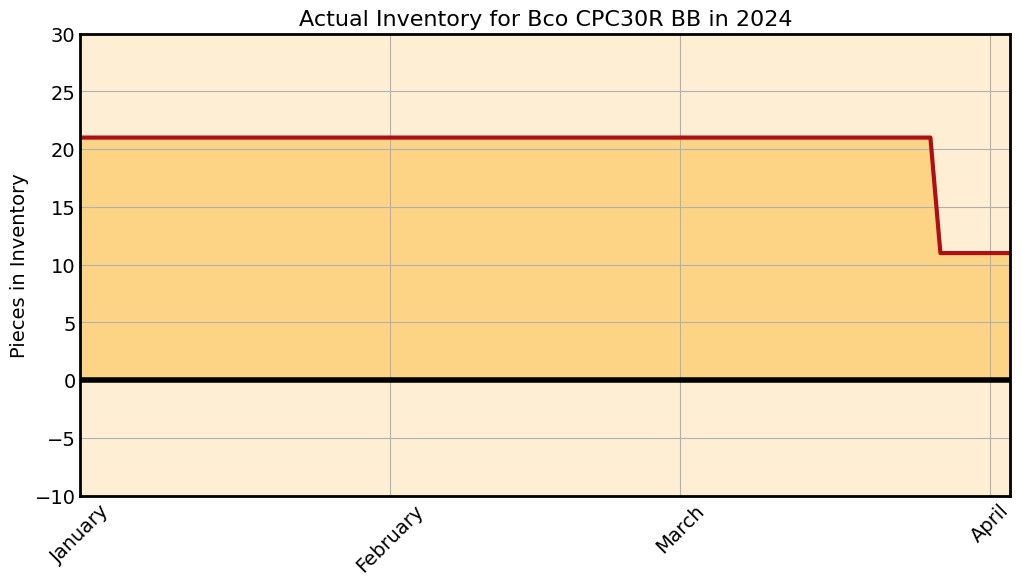

In [30]:
# prompt: change x limit of graph to only include date in "Date"

plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#feefd4') # Light orange background
plt.plot(DpP['Date'], DpP['Inventario'], color='#af0f14', linewidth=3) # Red thick line
plt.fill_between(DpP['Date'], DpP['Inventario'], color='#fdd486', alpha=1) # Orange fill
plt.axhline(y=0, color='black', linestyle='-', linewidth=4)

#plt.xlabel('Date', fontsize=14)
plt.ylabel('Pieces in Inventory', fontsize=14)
plt.title(f'Actual Inventory for {description} in 2024', fontsize=16)
plt.grid(True)
plt.ylim(-10,30)
plt.xlim(DpP['Date'].min(), DpP['Date'].max()) # Set x-limit to the date range in the DataFrame
plt.xticks(rotation=45)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14) # Increase tick label size
ax.xaxis.set_major_locator(mdates.MonthLocator()) # Set major ticks to every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B')) # Format ticks as full month name
ax.tick_params(axis='both',        # apply to both axes
               which='both',       # apply to major *and* minor ticks
               length=0)
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.savefig(f'Actual_Inv_{description}.png', dpi=300, bbox_inches='tight')
plt.show()

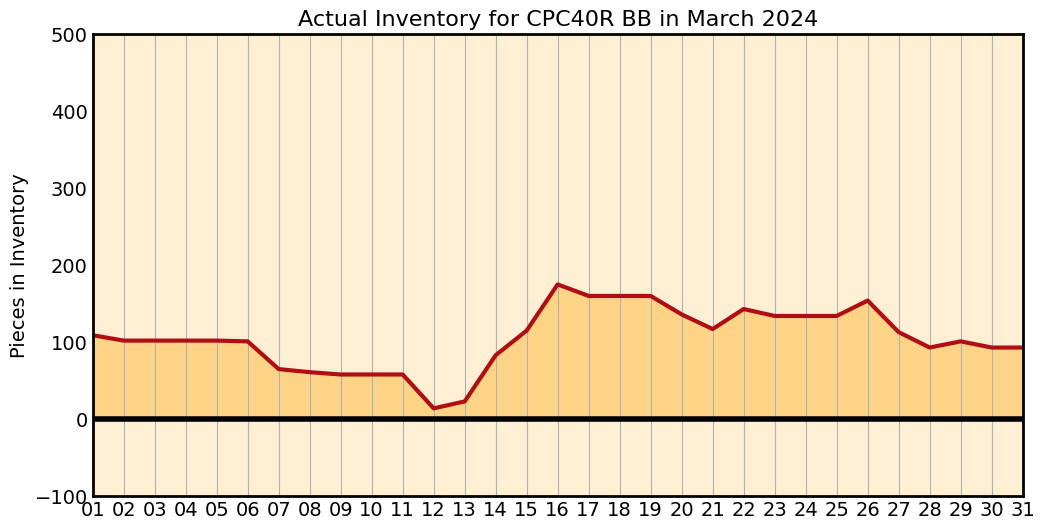

In [ ]:
# prompt: for the graph of "Inventario", plot only for a month. I will input the month

month_input = "March" #@param ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
month_number = pd.to_datetime(month_input, format='%B').month
DpP_month = DpP[DpP['Date'].dt.month == month_number].copy()

plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#feefd4') # Light orange background

plt.plot(DpP_month['Date'], DpP_month['Inventario'], color='#af0f14', linewidth=3) # Red thick line
plt.fill_between(DpP_month['Date'], DpP_month['Inventario'], color='#fdd486', alpha=1) # Orange fill
plt.axhline(y=0, color='black', linestyle='-', linewidth=4)

plt.ylabel('Pieces in Inventory', fontsize=14)
plt.title(f'Actual Inventory for {description} in {month_input} 2024', fontsize=16)
plt.grid(axis='x')

# Set x-limits to the start and end of the selected month
start_date = pd.to_datetime(f'2024-{month_number}-01')
end_date = start_date + pd.offsets.MonthEnd(0)
plt.ylim(-100,500)
plt.xlim(start_date, end_date)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14) # Increase tick label size
ax.xaxis.set_major_locator(mdates.DayLocator()) # Set major ticks every 5 days
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d')) # Format ticks as day number
ax.tick_params(axis='both',        # apply to both axes
               which='both',       # apply to major *and* minor ticks
               length=0)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.savefig(f'Actual_Inv_{description}_{month_input}.png', dpi=300, bbox_inches='tight')
plt.show()


In [23]:
def simulate_qr(
    DpP: pd.DataFrame,
    Q: int,
    R: int,
    lead_time: int,
    safety_stock: int = 0,
    allow_backorders: bool = True
) -> pd.DataFrame:
    """
    Simulate a (Q, R) continuous-review inventory policy.

    Inputs (columns expected in DpP):
    ---------------------------------
      Date         : time index (e.g. daily)
      Inventario   : opening on-hand for Day-0
      Demanda      : demand for each row
      Abasto       : the FIRST value is treated as an arrival that lands
                     on Day-0 *before* demand is filled

    Returns
    -------
      DataFrame with columns:
        Date, Simulated_Inventory, Orders_Placed, Arrivals, Demanda
    """
    # Copy only the needed columns to keep the original frame intact
    df = DpP[['Date', 'Inventario', 'Demanda', 'Abasto tránsito']].copy().reset_index(drop=True)

    # Initialise result columns
    df['Orders_Placed']       = 0
    df['Arrivals']            = 0
    df['Simulated_Inventory'] = 0

    # Starting on-hand inventory: opening stock + first-day Abasto
    first_arrival = float(df.loc[0, 'Abasto tránsito'])
    on_hand       = float(df.loc[0, 'Inventario']) #+ first_arrival

    # Record Day-0 arrival
    df.at[0, 'Arrivals'] = first_arrival

    # Pipeline = list of (arrival_day_index, quantity)
    pipeline = []

    for t in df.index:                                # iterate day by day
        # -----------------------------------------------------------------
        # 1. RECEIVE any orders that arrive today (already has Abasto on t=0)
        # -----------------------------------------------------------------
        arrivals_today = df.at[t, 'Arrivals']         # may already include Day-0 Abasto
        arrivals_today += sum(q for d, q in pipeline if d == t)
        if arrivals_today:
            on_hand += arrivals_today
        # Remove delivered orders from pipeline
        pipeline = [(d, q) for d, q in pipeline if d != t]

        # --------------------------------------------------------------
        # 2. SATISFY TODAY'S DEMAND (allow back-orders or lost-sales)
        # --------------------------------------------------------------
        demand_today = float(df.at[t, 'Demanda'])
        if allow_backorders:
            on_hand -= demand_today                   # negative = back-orders
        else:
            supplied    = min(on_hand, demand_today)
            on_hand    -= supplied                    # clip at zero
            # any unsupplied demand is lost

        # --------------------------------------------------------------
        # 3. REORDER RULE  — test AFTER demand is filled
        # --------------------------------------------------------------
        inventory_position = on_hand + sum(q for _, q in pipeline)
        orders_today = 0
        while inventory_position <= R:
            arrival_day = t + lead_time
            pipeline.append((arrival_day, Q))
            orders_today       += Q
            inventory_position += Q

        # --------------------------------------------------------------
        # 4. WRITE RESULTS FOR THE DAY
        # --------------------------------------------------------------
        df.at[t, 'Arrivals']            = arrivals_today
        df.at[t, 'Orders_Placed']       = orders_today
        df.at[t, 'Simulated_Inventory'] = on_hand

    # Return only the requested columns in the requested order
    return df[['Date',
               'Simulated_Inventory',
               'Orders_Placed',
               'Arrivals',
               'Demanda']]

Q=12
R=2
lead_time=3
safety_stock=1
simulation_results_df = simulate_qr(DpP, Q, R, lead_time)
simulation_results_df = simulation_results_df.rename(columns={'Simulated_Inventory': 'Inventory', 'Demanda': 'Demand'})
simulation_results_df.tail()

,Date,Inventory,Orders_Placed,Arrivals,Demand
89,2024-03-30,11,0,0,0
90,2024-03-31,11,0,0,0
91,2024-04-01,11,0,0,0
92,2024-04-02,11,0,0,0
93,2024-04-03,0,12,0,11


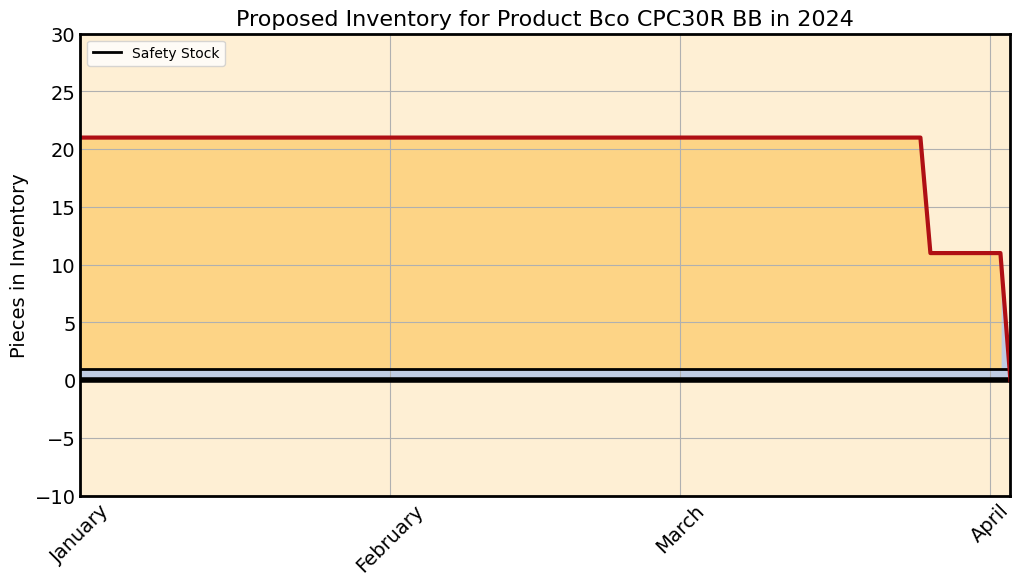

In [25]:
plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#feefd4')

# Fill between inventory and 0 when inventory is below safety stock
plt.fill_between(simulation_results_df['Date'], simulation_results_df['Inventory'], 0,
                 color='#bfcce3', alpha=1)
# Fill between inventory and safety stock when inventory is above safety stock
plt.fill_between(simulation_results_df['Date'], simulation_results_df['Inventory'], safety_stock,
                 where=(simulation_results_df['Inventory'] > safety_stock),
                 color='#fdd486', alpha=1)

plt.axhline(y=0, color='black', linestyle='-', linewidth=4)
#plt.axhline(y=target_inventory, color='black', linestyle='--', linewidth=2, label='Target Inventory') # Add target inventory line
plt.axhline(y=safety_stock, color='black', linewidth=2, label='Safety Stock') # Add safety stock line

plt.plot(simulation_results_df['Date'], simulation_results_df['Inventory'], color='#af0f14', linewidth=3)

plt.ylabel('Pieces in Inventory', fontsize=14)
plt.title(f'Proposed Inventory for Product {description} in 2024', fontsize=16)

plt.grid(True)
plt.ylim(-10,30)
plt.xlim(simulation_results_df['Date'].min(), simulation_results_df['Date'].max())
plt.xticks(rotation=45)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.tick_params(axis='both',
               which='both',
               length=0)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.legend(loc='upper left') # Add legend to show the label for target inventory line
plt.savefig(f'Proposed_Inv_{description}.png', dpi=300, bbox_inches='tight')
plt.show()

## Final Simulated Inventory Data

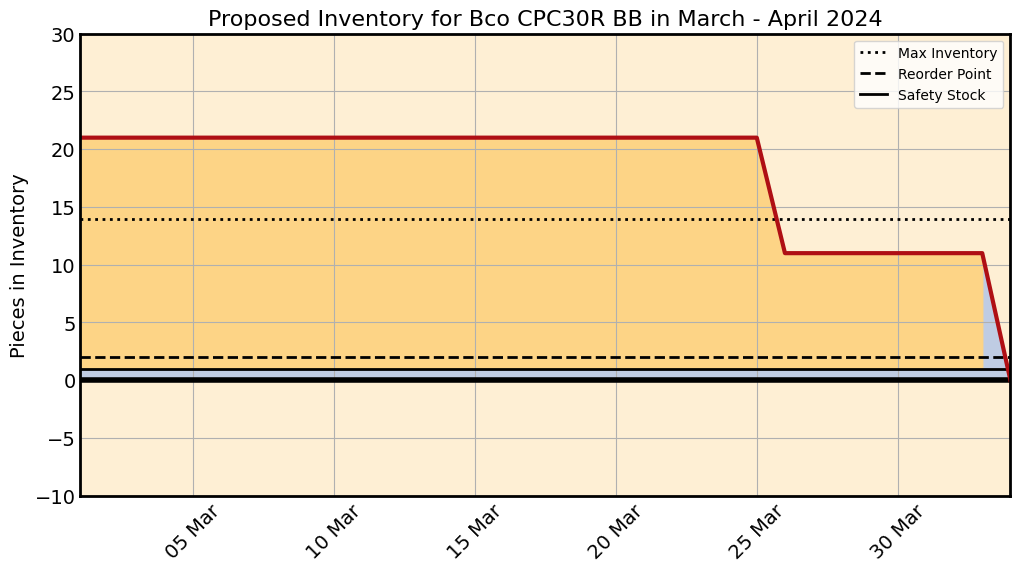

In [28]:
# prompt: now plot only two months

start_month_input = "March" #@param ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
end_month_input = "April" #@param ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

start_month_number = pd.to_datetime(start_month_input, format='%B').month
end_month_number = pd.to_datetime(end_month_input, format='%B').month

simulation_results_df_two_months = simulation_results_df[
    (simulation_results_df['Date'].dt.month >= start_month_number) &
    (simulation_results_df['Date'].dt.month <= end_month_number)
].copy()

plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#feefd4')

# Fill between inventory and 0 when inventory is below safety stock
plt.fill_between(simulation_results_df_two_months['Date'], simulation_results_df_two_months['Inventory'], 0,
                 color='#bfcce3', alpha=1)
# Fill between inventory and safety stock when inventory is above safety stock
plt.fill_between(simulation_results_df_two_months['Date'], simulation_results_df_two_months['Inventory'], safety_stock,
                 where=(simulation_results_df_two_months['Inventory'] > safety_stock),
                 color='#fdd486', alpha=1)
# Fill between inventory and safety stock when inventory is above safety stock
plt.fill_between(simulation_results_df_two_months['Date'], simulation_results_df_two_months['Inventory'], 0,
                 where=(simulation_results_df_two_months['Inventory'] <= 0),
                 color='red', alpha=1)

plt.axhline(y=Q+R, color='black', linestyle='dotted', linewidth=2, label='Max Inventory')
plt.axhline(y=R, color='black', linestyle='--', linewidth=2, label='Reorder Point')
plt.axhline(y=0, color='black', linestyle='-', linewidth=4)
plt.axhline(y=safety_stock, color='black', linewidth=2, label='Safety Stock')

plt.plot(simulation_results_df_two_months['Date'], simulation_results_df_two_months['Inventory'], color='#af0f14', linewidth=3)

plt.ylabel('Pieces in Inventory', fontsize=14)
plt.title(f'Proposed Inventory for {description} in {start_month_input} - {end_month_input} 2024', fontsize=16)

plt.grid(True)
plt.ylim(-10,30)
plt.xlim(simulation_results_df_two_months['Date'].min(), simulation_results_df_two_months['Date'].max())
plt.xticks(rotation=45)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5)) # Set major ticks every 5 days
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) # Format ticks as day number and abbreviated month
ax.tick_params(axis='both',
               which='both',
               length=0)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.legend(loc='upper right')
plt.savefig(f'Proposed_Inv_{description}_{start_month_input}_{end_month_input}.png', dpi=300, bbox_inches='tight')
plt.show()
